**<font color=skyblue>示範對影像做 Convolution 的效果</font>**

- Sharpen an image
- Detect the edges of an image

參考卷積 convolution 的矩陣運算：http://www.songho.ca/dsp/convolution/convolution2d_example.html


![Convolution](https://i.stack.imgur.com/9OZKF.gif)

<font size = 3>[動畫來源](https://pub.towardsai.net/image-classification-with-neural-network-21a75cebb067)</font>

*<font color=orange>Part I: Sharpen an blurred image</font>*

*<font color=yellow>首先對一個影像進行 Blurring</font>*

為了示範影像 sharpen 的效果，先將原影像 blurred，產生模糊化影像。

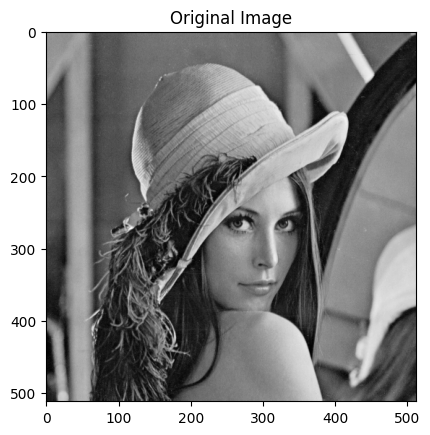

In [11]:
import matplotlib.pyplot as plt
from skimage import io

imgfile = "pictures/Lenna.png" # 512x512x3
original_img = io.imread(imgfile, as_gray = True)
plt.imshow(original_img, cmap = 'gray')
plt.title("Original Image")
plt.show()

*<font color=yellow>Create a kernel matrix that will serves as an operator to blur the original image</font>*

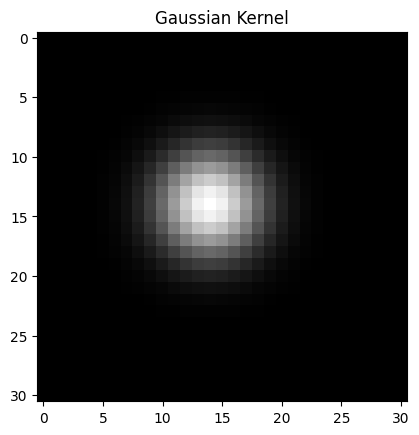

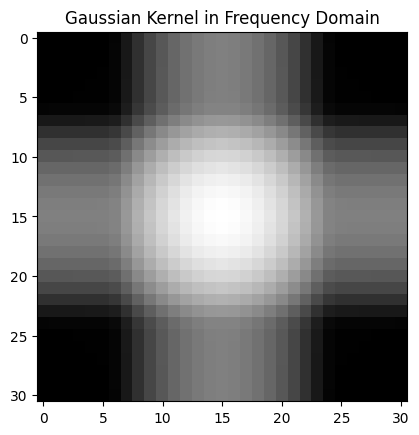

In [2]:
import numpy as np

ksize = 31
s = 3
m = ksize // 2
X, Y = np.meshgrid(np.arange(1, ksize+1), np.arange(1, ksize+1))
kernel = (1 / (2 * np.pi * s ** 2)) * np.exp(-((X - m) ** 2 + (Y - m) ** 2) / (2 * s ** 2))
kernel = kernel / np.sum(kernel)
plt.imshow(kernel, cmap = 'gray')
plt.title("Gaussian Kernel")
plt.show()

fftkernel = np.fft.fft2(kernel)
fftkernel = np.fft.fftshift(fftkernel)
plt.imshow(np.log(np.abs(fftkernel)), cmap = 'gray')
plt.title("Gaussian Kernel in Frequency Domain")
plt.show()



*<font color=yellow>將原影像與 Kernel matrix 做二維的 convolution</font>*

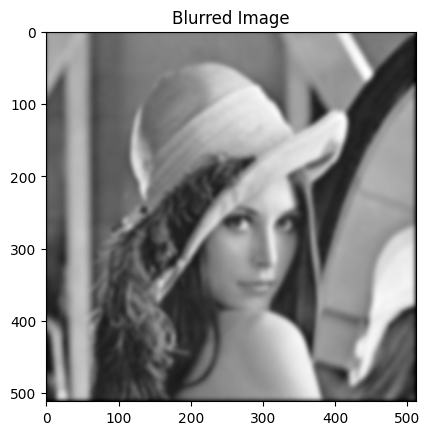

In [12]:
from scipy import signal

blur_by_conv = signal.convolve2d(original_img, kernel, mode='same', boundary='fill', fillvalue=0)
plt.imshow(blur_by_conv, cmap = 'gray')
plt.title("Blurred Image")
plt.show()

*<font color=yellow>Use scipy.ndimage.gaussian_filter to blur an image</font>*

The Gaussian kernel will have size 2*radius + 1 along each axis where radius = round(truncate * sigma)

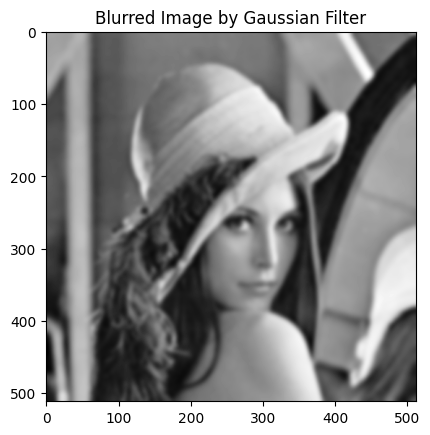

In [4]:
from scipy.ndimage import gaussian_filter

blur_by_gaussian = gaussian_filter(original_img, sigma = 3)
plt.imshow(blur_by_gaussian, cmap = 'gray')
plt.title("Blurred Image by Gaussian Filter")
plt.show()

*<font color=yellow>Another blurring kernel: motion blurring</font>*

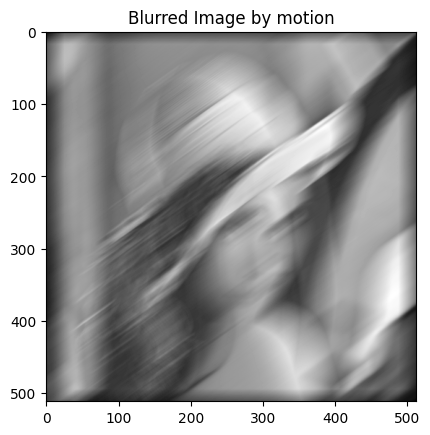

In [22]:
import numpy as np


def motion_kernel(length, angle):
    kernel = np.zeros((length, length))
    xcoord = ycoord = (length - 1) / 2
    angle = np.deg2rad(angle)
    dx = np.sin(angle)
    dy = np.cos(angle)
    for i in range(length):
        for j in range(length):
            x = int(np.round(xcoord - dx * (j - ycoord)))
            y = int(np.round(ycoord + dy * (j - ycoord)))
            if (x >= 0 and x < length and y >= 0 and y < length):
                kernel[i, j] = (i == x)
    kernel /= kernel.sum()
    return kernel

h = motion_kernel(50, 45)
motion_by_conv = signal.convolve2d(original_img, h, mode='same', boundary='fill', fillvalue=0)
plt.imshow(motion_by_conv, cmap = 'gray')
plt.title("Blurred Image by motion")
plt.show()

<hr>

*<font color=yellow>接著對 blurred image 進行 Sharpen</font>* 

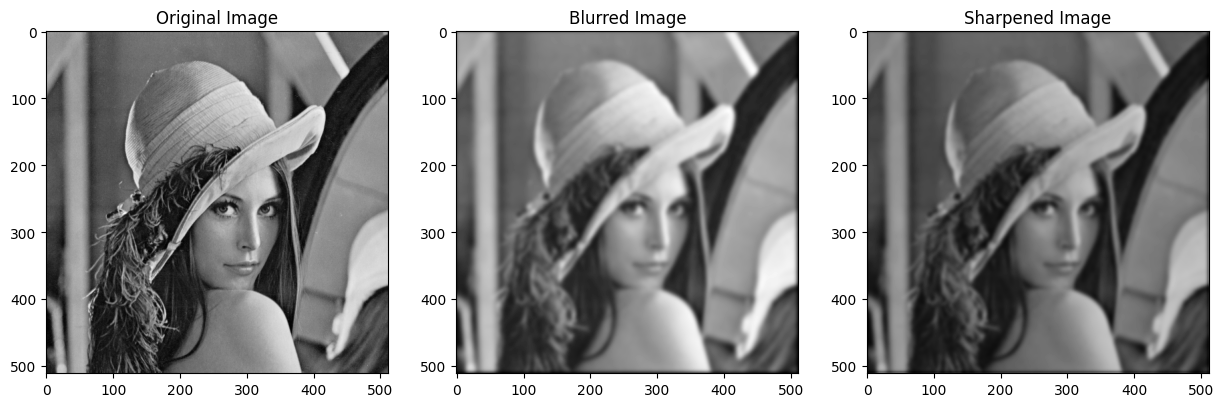

In [10]:
sharpen_kernel = np.array([[0, -1,  0],
                           [-1,  5, -1],
                           [0, -1,  0]]) # Laplacian kernel
# sharpen_kernel = np.array([[-1, -1, -1],[-1, 8, -1],[-1, -1, 0]]) / 3
# sharpen_kernel = np.array([[1, -2, 1],
#                            [-2, 5, -2],
#                            [1, -2, 1]])
# sharpen_kernel = np.array([[-0.0023, -0.0432, -0.0023],
#                            [-0.0432, 1.182, -0.0432],
#                            [-0.0023, -0.0432, -0.0023]])
sharpen_by_conv = signal.convolve2d(blur_by_conv, sharpen_kernel, mode='same', boundary='fill', fillvalue=0)

fig, ax = plt.subplots(1, 3, figsize = (15, 5))
ax[0].imshow(original_img, cmap = 'gray')
ax[0].set_title("Original Image")
ax[1].imshow(blur_by_conv, cmap = 'gray')
ax[1].set_title("Blurred Image")
ax[2].imshow(sharpen_by_conv, cmap = 'gray')
ax[2].set_title("Sharpened Image")
plt.show()

<hr>

*<font color=orange>Part II: Detect the edges of an image</font>*

參考：https://medium.com/@kdorichev/edges-detection-in-computer-vision-using-convolutions-5332efad3c91

*<font color=yellow>Detect vertical edges</font>* 

- kernel(x,y), the values in y direction change from negative to positive
- the reverse of kernel(x,y) also change its values in y direction, and that will cause the detection of vertical edges.

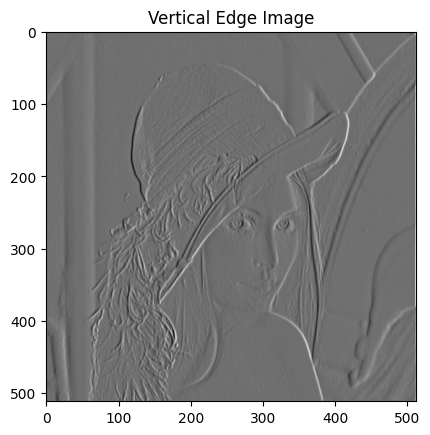

In [24]:
edge_v_kernel = np.array([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]]) # Prewitt
# edge_v_kernel = np.array([[-1.,0.,1.],[-2.,0.,2.],[-1.,0.,1.]])/8 # Sobel
edge_v_by_conv = signal.convolve2d(original_img, edge_v_kernel, mode='same', boundary='fill', fillvalue=0)
plt.imshow(edge_v_by_conv, cmap = 'gray')
plt.title("Vertical Edge Image")
plt.show()


*<font color=yellow>Detect horizontal edges</font>*

- kernel(x,y), the values in x direction change from nagative to positive
- the reverse of kernel(x,y) also change its values in x direction, and that will cause the detection of horizontal edges.

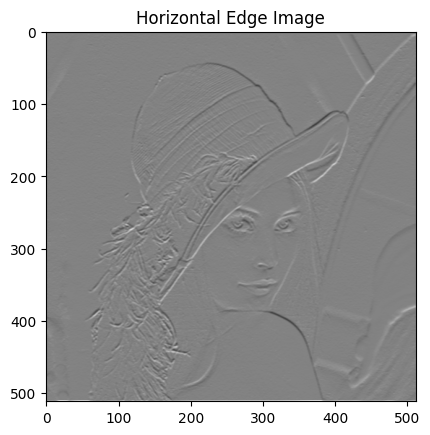

In [25]:
edge_h_kernel = np.array([[-1, -1, -1],
                          [0, 0, 0],
                          [1, 1, 1]])
# edge_h_kernel = np.array([[-1.,-2.,-1.],[0.,0.,0.],[1.,2.,1.]])/8 # Sobel
edge_h_by_conv = signal.convolve2d(original_img, edge_h_kernel, mode='same', boundary='fill', fillvalue=0)
plt.imshow(edge_h_by_conv, cmap = 'gray')
plt.title("Horizontal Edge Image")
plt.show()


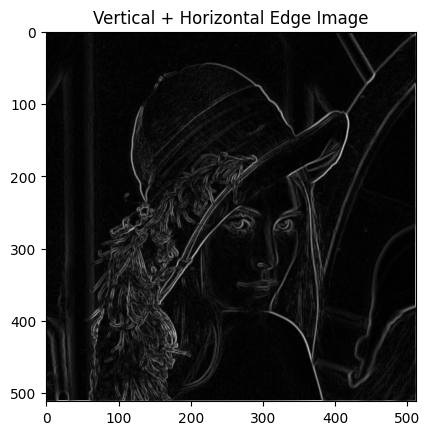

In [26]:
edge_v_h_by_conv = np.sqrt(edge_v_by_conv ** 2 + edge_h_by_conv ** 2)
plt.imshow(edge_v_h_by_conv, cmap = 'gray')
plt.title("Vertical + Horizontal Edge Image")
plt.show()

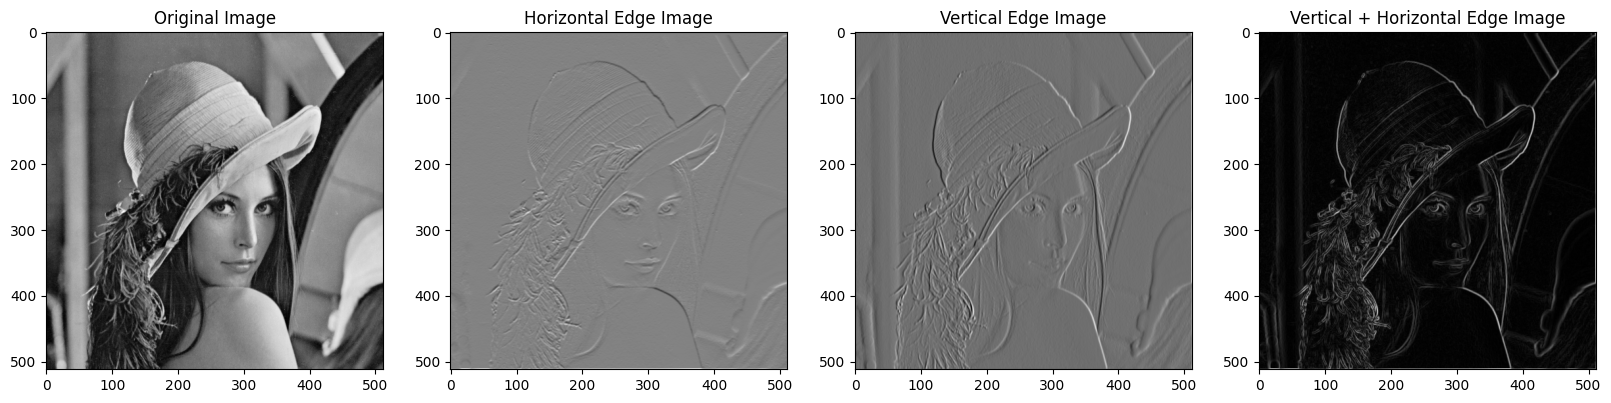

In [27]:
fig, ax = plt.subplots(1, 4, figsize = (20, 5))
ax[0].imshow(original_img, cmap = 'gray')
ax[0].set_title("Original Image")
ax[1].imshow(edge_h_by_conv, cmap = 'gray')
ax[1].set_title("Horizontal Edge Image")
ax[2].imshow(edge_v_by_conv, cmap = 'gray')
ax[2].set_title("Vertical Edge Image")
ax[3].imshow(edge_v_h_by_conv, cmap = 'gray')
ax[3].set_title("Vertical + Horizontal Edge Image")
plt.show()


*<font color=orange>Do the same thing by Torch</font>*

Need to adjust image size if use matplotlib to display images.

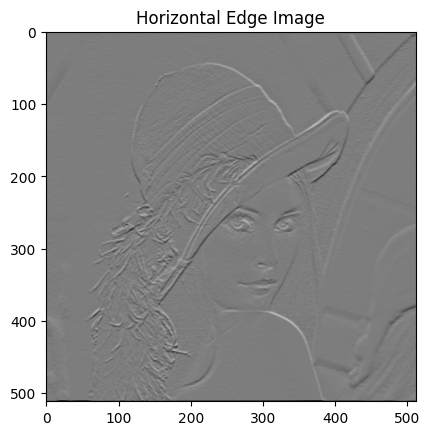

In [28]:
import torch
import torch.nn.functional as F
import torch.nn as nn

X_torch = torch.from_numpy(original_img).float()
# edge_h_kernel_torch = torch.tensor([[-1, -1, -1],
#                               [0, 0, 0],
#                               [1, 1, 1]])
X_torch = X_torch.reshape(1, 1, 512, 512) # (batch_size, channel, height, width)
h_torch = torch.from_numpy(edge_h_kernel).float()
h_torch = h_torch.reshape(1, 1, 3, 3) # (out_channel, in_channel, kernel_height, kernel_width)

edge_h_by_conv_torch = F.conv2d(X_torch, h_torch, padding = 1)
edge_h_by_conv_numpy = edge_h_by_conv_torch.numpy().squeeze() # (batch_size, channel, height, width) -> (height, width)

# edge_h_by_conv_torch = torch.nn.functional.conv2d(X_torch.unsqueeze(0).unsqueeze(0), h_torch.unsqueeze(0).unsqueeze(0), padding = 1)
# edge_h_by_conv_torch = edge_h_by_conv_torch.squeeze().squeeze().numpy()
plt.imshow(edge_h_by_conv_numpy, cmap = 'gray')
plt.title("Horizontal Edge Image")
plt.show()


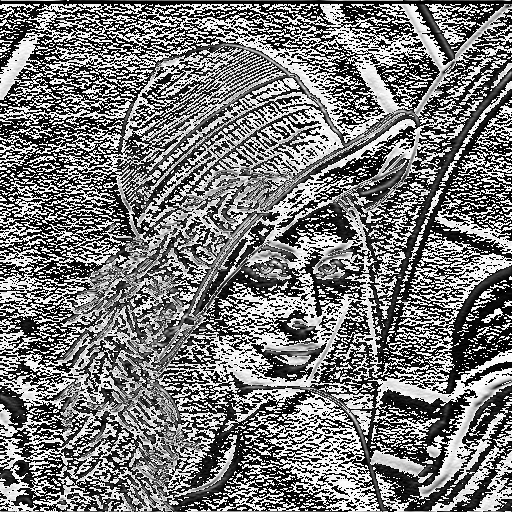

In [29]:
import torchvision.transforms as T

# T.ToPILImage()(edge_h_by_conv_torch[0])
T.ToPILImage()(edge_h_by_conv_torch.squeeze())



<hr>

*<font color=yellow>使用特別圖像來凸顯水平與垂直線的偵測</font>*

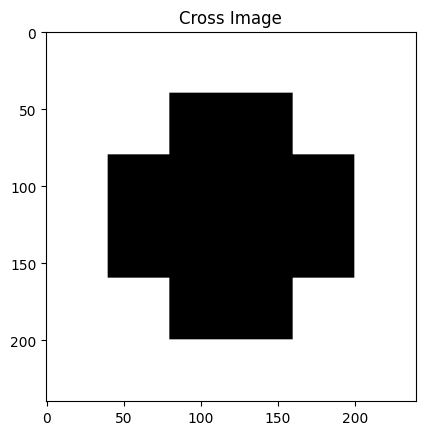

In [30]:
imsz = 240
cross = np.ones((imsz,imsz))
cross[int(imsz/3):int(2*imsz/3),int(imsz/6):int(5*imsz/6)]=0
cross[int(imsz/6):int(5*imsz/6),int(imsz/3):int(2*imsz/3)]=0
fig = plt.figure()
plt.imshow(cross, cmap = 'gray')
plt.title("Cross Image")
plt.show()

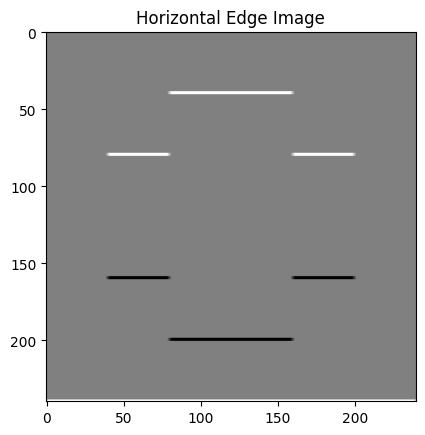

In [31]:
cross_edge_h_by_conv = signal.convolve2d(cross, edge_h_kernel, mode='same', boundary='fill', fillvalue=0)
plt.imshow(cross_edge_h_by_conv, cmap = 'gray')
plt.title("Horizontal Edge Image")
plt.show()

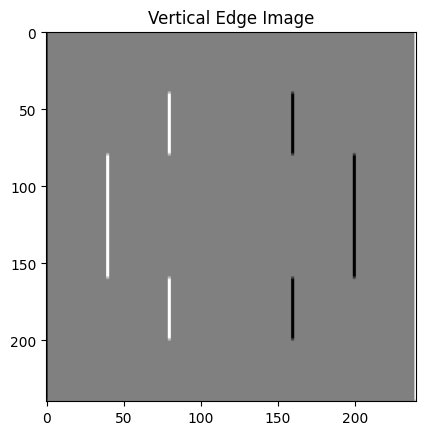

In [32]:
cross_edge_v_by_conv = signal.convolve2d(cross, edge_v_kernel, mode='same', boundary='fill', fillvalue=0)
plt.imshow(cross_edge_v_by_conv, cmap = 'gray')
plt.title("Vertical Edge Image")
plt.show()

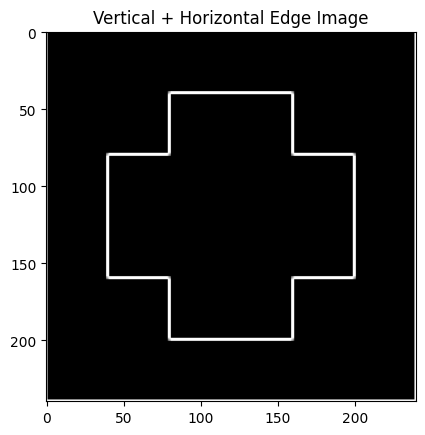

In [ ]:
corss_v_h_by_conv = np.sqrt(cross_edge_v_by_conv ** 2 + cross_edge_h_by_conv ** 2)
plt.imshow(corss_v_h_by_conv, cmap = 'gray')
plt.title("Vertical + Horizontal Edge Image")
plt.show()

In [ ]:
p = cross[120:125,36:44]
print(p)
print(edge_h_kernel)
q = signal.convolve2d(p, edge_h_kernel, mode='same', boundary='fill', fillvalue=0)
print(q)

[[1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0.]]
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]
[[-2.  0.  0.  2.  2.  0.  0.  0.]
 [-3.  0.  0.  3.  3.  0.  0.  0.]
 [-3.  0.  0.  3.  3.  0.  0.  0.]
 [-3.  0.  0.  3.  3.  0.  0.  0.]
 [-2.  0.  0.  2.  2.  0.  0.  0.]]
